In [21]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Optional
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv
from typing import TypedDict

In [22]:
from typing import TypedDict

class OrderState(TypedDict):
    order_amount: int
    user_type: str
    discount: int
    shipping: str

In [5]:
def apply_discount(state: OrderState):
    return {"discount": 100}


def no_discount(state: OrderState):
    return {"discount": 0}


def priority_shipping(state: OrderState):
    return {"shipping": "Priority Shipping"}


def standard_shipping(state: OrderState):
    return {"shipping": "Standard Shipping"}

In [7]:
def discount_decision(state: OrderState):
    if state["order_amount"] > 1000:
        return "discount"
    return "no_discount"


def shipping_decision(state: OrderState):
    if state["user_type"] == "premium":
        return "priority"
    return "standard"

In [8]:
graph = StateGraph(OrderState)

# nodes
graph.add_node("apply_discount", apply_discount)
graph.add_node("no_discount", no_discount)
graph.add_node("priority_shipping", priority_shipping)
graph.add_node("standard_shipping", standard_shipping)

In [9]:
graph.add_conditional_edges(
    "__start__",
    discount_decision,
    {
        "discount": "apply_discount",
        "no_discount": "no_discount"
    }
)

In [10]:
graph.add_conditional_edges(
    "apply_discount",
    shipping_decision,
    {
        "priority": "priority_shipping",
        "standard": "standard_shipping"
    }
)

graph.add_conditional_edges(
    "no_discount",
    shipping_decision,
    {
        "priority": "priority_shipping",
        "standard": "standard_shipping"
    }
)

In [11]:
graph.add_edge("priority_shipping", END)
graph.add_edge("standard_shipping", END)

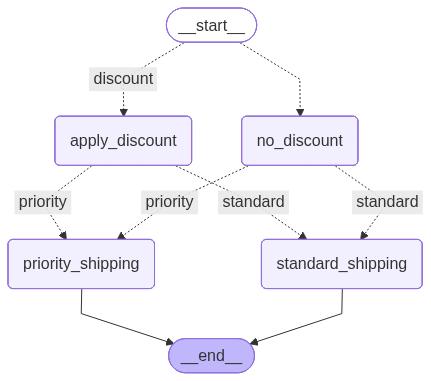

In [12]:
workflow = graph.compile()
workflow

In [13]:
result = workflow.invoke({
    "order_amount": 1200,
    "user_type": "premium"
})

print(result)

{'order_amount': 1200, 'user_type': 'premium', 'discount': 100, 'shipping': 'Priority Shipping'}


In [23]:
# simple work flow:
from typing import Literal


class SentimentSchema(BaseModel):

    sentiment : Literal['positive', 'negative'] = Field(description='Sentiment of the review')


In [24]:
model = ChatOpenAI(model='gpt-4o-mini')

In [25]:
structured_model = model.with_structured_output(SentimentSchema)

prompt = """
i had a good experience with this phone
"""

result = structured_model.invoke(prompt)

result.sentiment

'positive'

In [26]:
# define state
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [55]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [56]:
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [67]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}
    

In [68]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

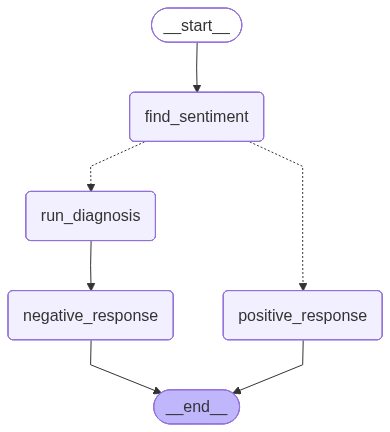

In [69]:
workflow

In [70]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help!\n\nHi [User's Name],\n\nI truly understand how frustrating it can be when things don’t work as expected, especially with a high urgency involved. I’m here to help you resolve the bug you’re experiencing.\n\nCould you please provide me with a few more details about the issue? Specifically, any error messages you’re seeing, the steps you took before encountering the bug, and the device or platform you’re using. With this information, I’ll be able to assist you more effectively.\n\nThank you for your patience, and I'm committed to getting this resolved for you as quickly as possible.\n\nBest regards,  \n